##MODELO PARA PREDECIR EL PRECIO DE UN AUTO NUEVO

#Nombre: Francisco Gil


# DATASET : https://www.kaggle.com/datasets/alemazz11/cars-europe


In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("alemazz11/cars-europe")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'cars-europe' dataset.
Path to dataset files: /kaggle/input/cars-europe


In [ ]:
!ls /root/.cache/kagglehub/datasets/alemazz11/cars-europe/versions/1

fullGas.csv


In [ ]:
PATH_CSV = path + '/fullGas.csv'

In [ ]:
%run '/content/pandas_missing_extension (1).ipynb'

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
sns.set(style='whitegrid',context='notebook')

In [ ]:
df = pd.read_csv(PATH_CSV)
df.head(10)

,Make,Model,Body,Mileage_km,Price,Year,Country,Condition,Fuel_Type,Fuel_Consumption_l,...,Cylinders,Seats,Doors,Color,Upholstery,Full_Service_History,Non_Smoker_Vehicle,Previous_Owners,Seller,Image_url
0,Abarth,595,Compact,98000,16900,2020.0,IT,Used,Gasoline,6.7,...,4.0,4.0,3.0,White,Full leather,False,False,NaN,Dealer,https://prod.pictures.autoscout24.net/listing-...
1,Abarth,595,Sedan,91500,12500,2017.0,IT,Used,Gasoline,6.0,...,4.0,4.0,3.0,Grey,Full leather,False,True,4.0,Dealer,https://prod.pictures.autoscout24.net/listing-...
2,Abarth,595,Compact,40000,17990,2015.0,IT,Used,Gasoline,6.5,...,4.0,4.0,3.0,Bronze,Full leather,True,True,1.0,Dealer,https://prod.pictures.autoscout24.net/listing-...
3,Abarth,500,Compact,133000,9300,2008.0,IT,Used,Gasoline,6.5,...,4.0,4.0,3.0,Black,Cloth,True,True,2.0,Dealer,https://prod.pictures.autoscout24.net/listing-...
4,Abarth,595,Compact,61019,14990,2021.0,BE,Used,Gasoline,NaN,...,4.0,4.0,3.0,Yellow,Part leather,True,True,1.0,Dealer,https://prod.pictures.autoscout24.net/listing-...
5,Abarth,595 Competizione,Sedan,7423,23300,2019.0,DE,Used,Gasoline,6.5,...,4.0,4.0,3.0,Grey,Full leather,True,True,1.0,Dealer,https://prod.pictures.autoscout24.net/listing-...
6,Abarth,595,Compact,66678,14900,2019.0,IT,Used,Gasoline,6.6,...,4.0,4.0,3.0,Grey,Cloth,False,False,NaN,Dealer,https://prod.pictures.autoscout24.net/listing-...
7,Abarth,695,Compact,98000,17990,2019.0,IT,Used,Gasoline,6.7,...,4.0,4.0,3.0,Grey,Full leather,True,True,1.0,Dealer,https://prod.pictures.autoscout24.net/listing-...
8,Abarth,595 Competizione,Compact,29999,18800,2018.0,BE,Used,Gasoline,6.8,...,4.0,4.0,3.0,Grey,alcantara,False,False,1.0,Dealer,https://prod.pictures.autoscout24.net/listing-...
9,Abarth,500e,Sedan,4230,25990,2025.0,BE,Used,Electric,NaN,...,NaN,4.0,3.0,Black,alcantara,True,False,NaN,Dealer,https://prod.pictures.autoscout24.net/listing-...


In [ ]:
df.shape

(40494, 25)

In [ ]:
df['Condition'].value_counts()

,count
Condition,
Used,38701
New,1793


#1-LIMPIEZA DEL DATASET

In [ ]:
df_clean = df.copy()

In [ ]:
cols_eliminar = ['Image_url']
df_clean.drop(columns=cols_eliminar, errors='ignore', inplace=True)

In [ ]:
df_clean.columns

Index(['Make', 'Model', 'Body', 'Mileage_km', 'Price', 'Year', 'Country',
       'Condition', 'Fuel_Type', 'Fuel_Consumption_l', 'Drivetrain', 'Gearbox',
       'Gears', 'Power_hp', 'Engine_Size_cc', 'Cylinders', 'Seats', 'Doors',
       'Color', 'Upholstery', 'Full_Service_History', 'Non_Smoker_Vehicle',
       'Previous_Owners', 'Seller'],
      dtype='object')

In [ ]:
umbral_nulos = 0.50
cols_muchos_nulos = [c for c in df_clean.columns
                     if df_clean[c].isnull().mean() > umbral_nulos]
print(f"Columnas eliminadas por >50% nulos: {cols_muchos_nulos}")
df_clean.drop(columns=cols_muchos_nulos, inplace=True)

Columnas eliminadas por >50% nulos: ['Fuel_Consumption_l']


#2-CASOS ATIPICOS

In [ ]:
df_clean = df_clean[(df_clean['Price'] >= 500) & (df_clean['Price'] <= 500_000)]

#3-EDA

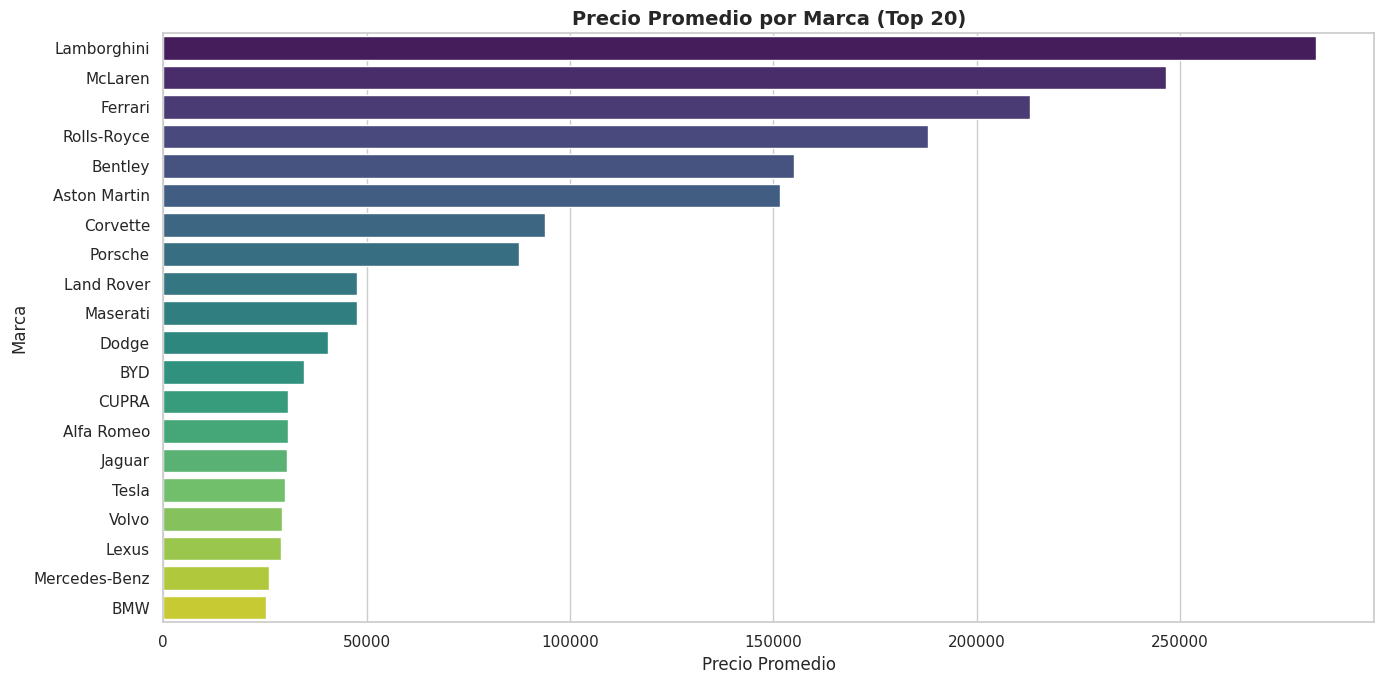

In [ ]:
avg_price_by_make = df_clean.groupby('Make')['Price'].mean().sort_values(ascending=False).head(20)

plt.figure(figsize=(14, 7))
sns.barplot(x=avg_price_by_make.values, y=avg_price_by_make.index,
            hue=avg_price_by_make.index, palette='viridis', legend=False)
plt.title('Precio Promedio por Marca (Top 20)', fontsize=14, fontweight='bold')
plt.xlabel('Precio Promedio')
plt.ylabel('Marca')
plt.tight_layout()
plt.show()

In [ ]:
df_clean['Price'].mean()

np.float64(44490.48373628022)

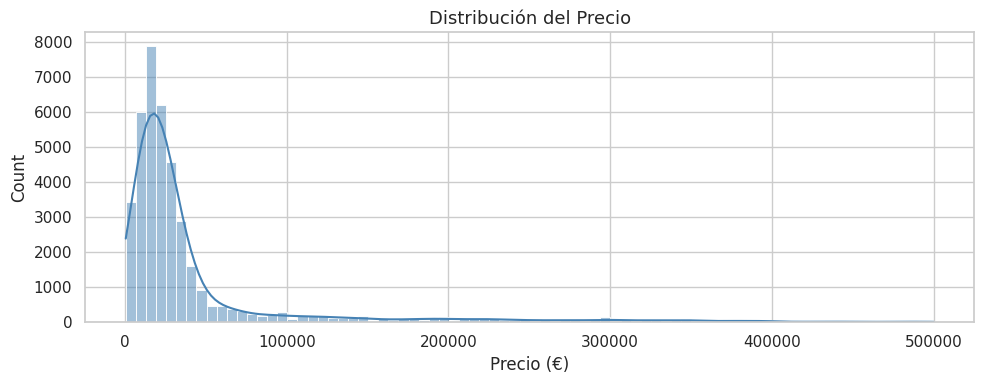

In [ ]:
plt.figure(figsize=(10, 4))
sns.histplot(df_clean['Price'], bins=80, kde=True, color='steelblue')
plt.title('Distribución del Precio', fontsize=13)
plt.xlabel('Precio (€)')
plt.tight_layout()
plt.show()

In [ ]:
variable = 'Price'
data = df_clean[variable]

mean_val   = data.mean()
median_val = data.median()
mode_val   = data.mode()[0]
q1  = data.quantile(0.25)
q3  = data.quantile(0.75)
iqr = q3 - q1
limite_inferior = q1 - 1.5 * iqr
limite_superior = q3 + 1.5 * iqr
outliers = data[(data < limite_inferior) | (data > limite_superior)]

print(f"📊 Medidas de tendencia central — {variable}")
print(f"   Media:   {mean_val:,.0f}")
print(f"   Mediana: {median_val:,.0f}")
print(f"   Moda:    {mode_val:,.0f}")
print(f"\n📈 Medidas de dispersión — {variable}")
print(f"   Desviación estándar: {data.std():,.0f}")
print(f"   IQR:                 {iqr:,.0f}")
print(f"\n⚠️  Detección de Outliers (IQR)")
print(f"   Límite inferior: {limite_inferior:,.0f}")
print(f"   Límite superior: {limite_superior:,.0f}")
print(f"   Outliers detectados: {len(outliers):,}")

📊 Medidas de tendencia central — Price
   Media:   44,490
   Mediana: 21,990
   Moda:    14,990

📈 Medidas de dispersión — Price
   Desviación estándar: 71,491
   IQR:                 21,950

⚠️  Detección de Outliers (IQR)
   Límite inferior: -19,425
   Límite superior: 68,375
   Outliers detectados: 5,265


In [ ]:
df_clean = df_clean[
    (df_clean['Price'] >= limite_inferior) &
    (df_clean['Price'] <= limite_superior)
]
print(f"\n Filas tras eliminar outliers IQR: {len(df_clean):,}")


 Filas tras eliminar outliers IQR: 34,732


#4-IMPUTACION DE NULOS

In [ ]:
df_clean.isnull().sum()[df_clean.isnull().sum() > 0]

,0
Model,125
Body,1
Year,1167
Country,2269
Fuel_Type,21
Drivetrain,7107
Gearbox,383
Gears,12751
Engine_Size_cc,5020
Cylinders,8425


In [ ]:
(df_clean.isnull().mean()*100).sort_values(ascending=False)

,0
Previous_Owners,43.308764
Gears,36.712542
Cylinders,24.257169
Drivetrain,20.462398
Upholstery,17.741564
Engine_Size_cc,14.453530
Country,6.532880
Color,6.469538
Seats,3.581711
Year,3.360014


In [ ]:
num_cols = df_clean.select_dtypes(include=['int64','float64']).columns.drop('Price')
cat_cols = df_clean.select_dtypes(include=['object','category']).columns

for col in num_cols:
    if df_clean[col].isnull().any():
        df_clean[col].fillna(df_clean[col].median(), inplace=True)

for col in cat_cols:
    if df_clean[col].isnull().any():
        df_clean[col].fillna(df_clean[col].mode()[0], inplace=True)

/tmp/ipykernel_40751/3576282702.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_clean[col].fillna(df_clean[col].median(), inplace=True)
/tmp/ipykernel_40751/3576282702.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace

In [ ]:
df_clean.isnull().sum()[df_clean.isnull().sum() > 0]

,0


#5-PREPARACIÓN DE FEATURES

In [ ]:
y = df_clean['Price']
X = df_clean.drop(columns=['Price'])

In [ ]:
X = pd.get_dummies(X, drop_first=True)

In [ ]:
print(f"📊 Shape de X: {X.shape}")
print(f"📊 Shape de y: {y.shape}")

📊 Shape de X: (34732, 1231)
📊 Shape de y: (34732,)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"\n🏋️  Train: {X_train.shape[0]:,} | 🧪 Test: {X_test.shape[0]:,}")


🏋️  Train: 27,785 | 🧪 Test: 6,947


In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # fit solo en train para evitar data leakage
X_test_scaled  = scaler.transform(X_test)

#6-ENTRENAMIENTO DE MODELOS

In [ ]:
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)
y_pred_lr = lr_model.predict(X_test_scaled)



In [ ]:
rf_model = RandomForestRegressor(n_estimators=200, max_depth=15,random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

In [ ]:
def evaluar_modelo(nombre, y_real, y_pred):
    mse = mean_squared_error(y_real, y_pred)
    r2  = r2_score(y_real, y_pred)
    print(f"\n{'='*45}")
    print(f"  {nombre}")
    print(f"{'='*45}")
    print(f"  MSE  (Error cuadrático medio):  {mse:,.0f}")
    print(f"  R2   (Bondad de ajuste):         {r2:.4f}")
    return {'Modelo': nombre, 'MSE': mse, 'R2': r2}

res_lr = evaluar_modelo("Regresión Lineal", y_test, y_pred_lr)
res_rf = evaluar_modelo("Random Forest",    y_test, y_pred_rf)

comparacion = pd.DataFrame([res_lr, res_rf]).set_index('Modelo')
print("\n📊 Tabla comparativa:")
display(comparacion.round(2))


  Regresión Lineal
  MSE  (Error cuadrático medio):  40,891,073
  R2   (Bondad de ajuste):         0.7635

  Random Forest
  MSE  (Error cuadrático medio):  20,767,159
  R2   (Bondad de ajuste):         0.8799

📊 Tabla comparativa:


,MSE,R2
Modelo,,
Regresión Lineal,40891073.24,0.76
Random Forest,20767159.46,0.88


#7-TABLA DE PREDICCIONES VS REAL

In [ ]:
results_df = pd.DataFrame({
    'Precio_Real':         y_test.values,
    'Prediccion_LinReg':   y_pred_lr.round(0),
    'Prediccion_RF':       y_pred_rf.round(0),
    'Error_LinReg (€)':    (y_pred_lr - y_test.values).round(0),
    'Error_RF (€)':        (y_pred_rf - y_test.values).round(0),
}, index=y_test.index)

results_df = results_df.merge(
    df_clean.loc[y_test.index][['Make']],
    left_index=True, right_index=True
)

print("🔍 Muestra de predicciones:")
display(results_df.head(10))

🔍 Muestra de predicciones:


,Precio_Real,Prediccion_LinReg,Prediccion_RF,Error_LinReg (€),Error_RF (€),Make
34922,24990,20307.0,19695.0,-4683.0,-5295.0,Skoda
6501,2350,6287.0,6433.0,3937.0,4083.0,Chevrolet
29160,1495,-1430.0,2388.0,-2925.0,893.0,Opel
15312,16990,21125.0,17601.0,4135.0,611.0,Hyundai
1304,26899,30050.0,28073.0,3151.0,1174.0,Alfa Romeo
11827,53900,58407.0,47601.0,4507.0,-6299.0,Ferrari
7281,4400,2736.0,4869.0,-1664.0,469.0,Chevrolet
30058,13500,10752.0,13530.0,-2748.0,30.0,Opel
5379,22430,23291.0,24415.0,861.0,1985.0,BMW
15245,25190,24661.0,28625.0,-529.0,3435.0,Hyundai
